In [1]:
import pandas as pd
import glob
import os

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kamaruladha/mental-disorders-identification-reddit-nlp")

print("Path to dataset files:", path)

Path to dataset files: /Users/snigdha/.cache/kagglehub/datasets/kamaruladha/mental-disorders-identification-reddit-nlp/versions/2


In [7]:
import os

path = "/Users/snigdha/.cache/kagglehub/datasets/kamaruladha/mental-disorders-identification-reddit-nlp/versions/2"

print(os.listdir(path))

['mental_disorders_reddit.csv']


In [8]:
import pandas as pd

path = "/Users/snigdha/.cache/kagglehub/datasets/kamaruladha/mental-disorders-identification-reddit-nlp/versions/2"

df = pd.read_csv(f"{path}/mental_disorders_reddit.csv")  

print(df.shape)
df.head()

(701787, 5)


,title,selftext,created_utc,over_18,subreddit
0,Life is so pointless without others,Does anyone else think the most important part...,1650356960,False,BPD
1,Cold rage?,Hello fellow friends 😄\n\nI'm on the BPD spect...,1650356660,False,BPD
2,I don’t know who I am,My [F20] bf [M20] told me today (after I said ...,1650355379,False,BPD
3,HELP! Opinions! Advice!,"Okay, I’m about to open up about many things I...",1650353430,False,BPD
4,help,[removed],1650350907,False,BPD


In [9]:
df = df.dropna(how='all')

In [10]:
df.isnull().sum()

title             46
selftext       33691
created_utc        0
over_18            0
subreddit          0
dtype: int64

In [11]:
df

,title,selftext,created_utc,over_18,subreddit
0,Life is so pointless without others,Does anyone else think the most important part...,1650356960,False,BPD
1,Cold rage?,Hello fellow friends 😄\n\nI'm on the BPD spect...,1650356660,False,BPD
2,I don’t know who I am,My [F20] bf [M20] told me today (after I said ...,1650355379,False,BPD
3,HELP! Opinions! Advice!,"Okay, I’m about to open up about many things I...",1650353430,False,BPD
4,help,[removed],1650350907,False,BPD
...,...,...,...,...,...
701782,Where can you go to get help for someone menta...,Someone (a war veteran) I know is mentally ill...,1396298261,False,mentalillness
701783,I am rooster illusion,AMA,1344639905,False,mentalillness
701784,I look again to make sure so one is near me an...,NaN,1353891546,False,mentalillness
701785,"NAMI | Peer-to-Peer is a unique, experiential ...",NaN,1348724331,False,mentalillness


In [12]:
df_sample = df.sample(100000, random_state=42)

In [13]:
df_sample["subreddit"].value_counts()

subreddit
BPD              34383
Anxiety          24929
depression       22145
mentalillness     7536
bipolar           7315
schizophrenia     3692
Name: count, dtype: int64

In [14]:
(df_sample["selftext"].str.strip() == "").mean()

np.float64(2e-05)

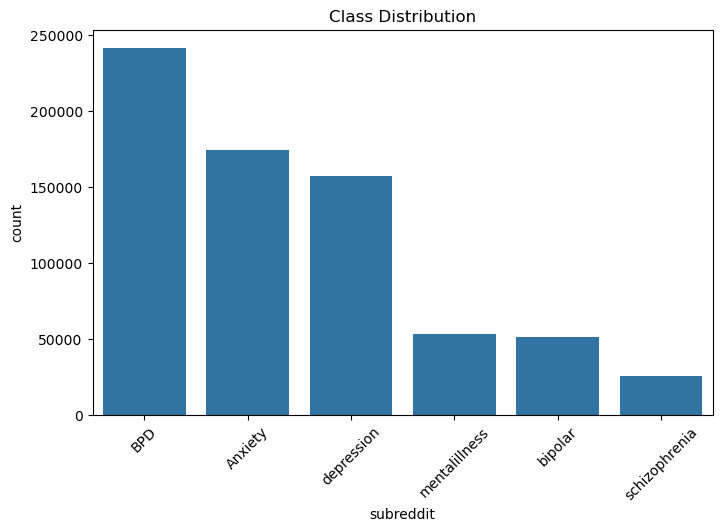

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x="subreddit", data=df, order=df["subreddit"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [16]:
(df["selftext"].isnull().mean()) * 100


np.float64(4.8007443854046885)

In [17]:
df["title"] = df["title"].fillna("")
df["selftext"] = df["selftext"].fillna("")

df["text"] = df["title"] + " " + df["selftext"]

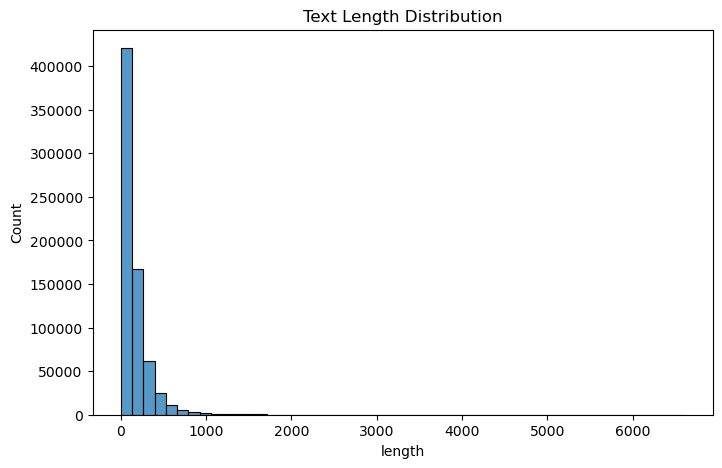

In [18]:
df["length"] = df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df["length"], bins=50)
plt.title("Text Length Distribution")
plt.show()

The distribution of text length is heavily right-skewed, with the majority of posts being relatively short while a small number of posts are extremely long. This indicates high variability in user-generated content.

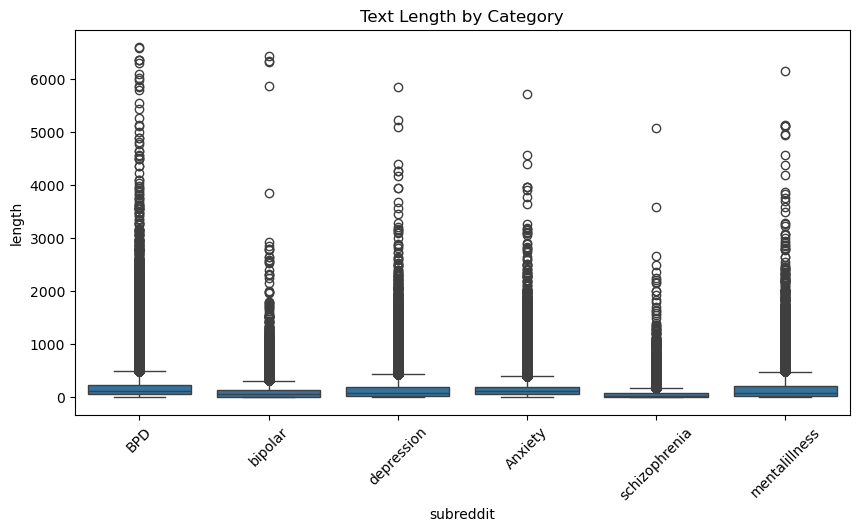

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x="subreddit", y="length", data=df)
plt.xticks(rotation=45)
plt.title("Text Length by Category")
plt.show()

The distribution of text length is heavily right-skewed, with the majority of posts being relatively short while a small number of posts are extremely long. This indicates high variability in user-generated content.

In [20]:
from collections import Counter
import re

def clean_words(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text.lower())
    return text.split()

words = []
for t in df["text"].sample(10000):
    words.extend(clean_words(t))

Counter(words).most_common(20)

[('i', 87367),
 ('and', 50564),
 ('to', 50019),
 ('the', 32332),
 ('my', 30718),
 ('a', 30026),
 ('of', 22628),
 ('me', 21120),
 ('it', 19891),
 ('that', 17823),
 ('im', 16565),
 ('in', 16211),
 ('but', 15308),
 ('for', 14257),
 ('is', 13764),
 ('have', 13478),
 ('with', 13361),
 ('this', 13224),
 ('just', 11910),
 ('so', 11780)]

In [21]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


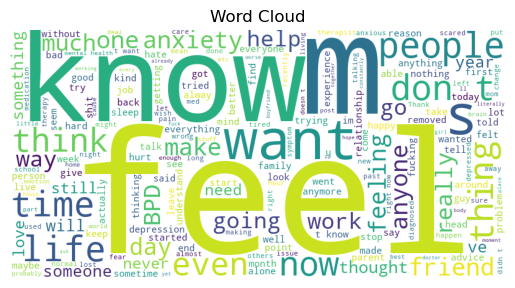

In [22]:
from wordcloud import WordCloud

wc = WordCloud(width=800, height=400, background_color="white") \
        .generate(" ".join(df["text"].sample(10000)))

plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

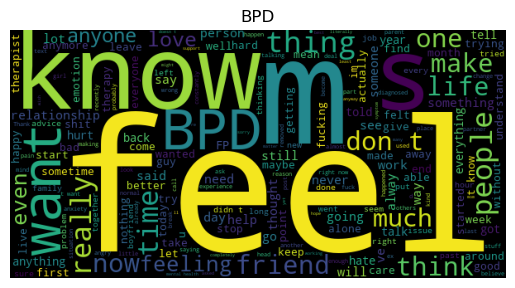

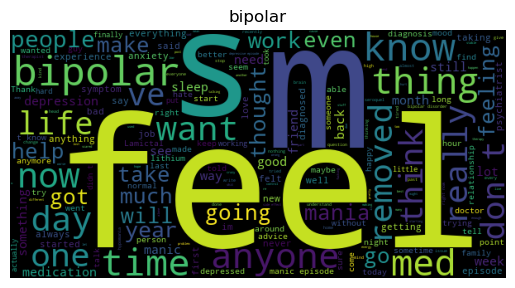

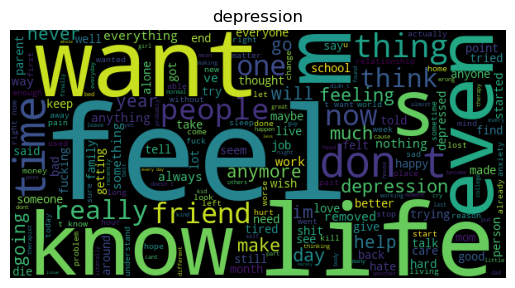

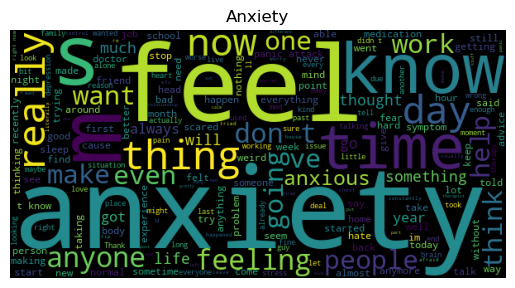

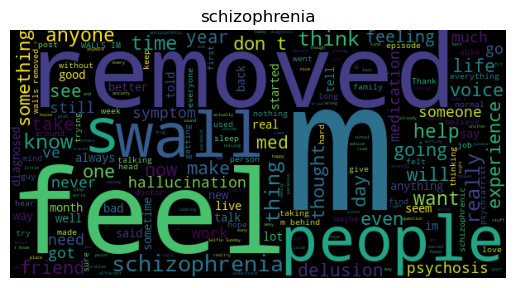

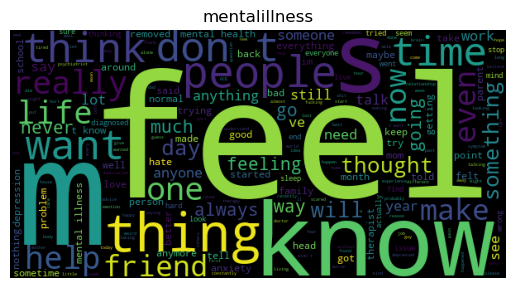

In [23]:
for sub in df["subreddit"].unique():
    sample_text = " ".join(df[df["subreddit"] == sub]["text"].sample(2000))
    
    wc = WordCloud(width=600, height=300).generate(sample_text)
    
    plt.imshow(wc)
    plt.axis("off")
    plt.title(sub)
    plt.show()

In [24]:
df["over_18"].value_counts()

over_18
False    682833
True      18954
Name: count, dtype: int64